<a href="https://colab.research.google.com/github/amjsebas/proyecto-final-IA-finanzas-aerolineas-2/blob/main/notebooks/analisis_exploratorio.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sistema Multi-Factor de Senales de Trading con LLMs

**Curso:** Modelos de Inteligencia Artificial para Finanzas - EGADE Business School
**Profesor:** Luis Angel Lozano Medina
**Entrega:** 08 de junio de 2026
**Equipo:** Mauricio Jazo, Sebastian Aceves, Jose Hernandez

**Universo:** AAL, DAL, UAL, LUV, JBLU, ULCC | **Benchmark:** ETF JETS | **Horizonte:** 5 dias habiles

Notebook v3 - rebuildeado limpio. Cada celda es idempotente, los checkpoints viven en `/content/saved/` (sobrevive runtime restarts), y hay smoke test de Gemini ANTES del loop grande.

**Para correr:** Runtime -> Restart and Run All. Te pide PAT + Gemini key. Tarda ~25-30 min.

## Paso 0 - Setup

In [ ]:
# Pin combo conocido como compatible (sin RuntimeError de torchvision::nms)
!pip install --quiet --upgrade yfinance finvizfinance ta google-generativeai econml numpy
!pip install --quiet torch==2.5.1 torchvision==0.20.1 transformers==4.46.0 --force-reinstall
print("Dependencias instaladas. Si Colab te avisa de un restart, ignoralo - los pins son compatibles.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.9/60.9 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.2/19.2 MB 755.7 kB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 5.50.0 requires pillow<12.0,>=8.0, but you have pillow 12.2.0 which is incompatible.
datasets 4.0.0 requires fsspec[http]<=2025.3.0,>=2023.1.0, but you have fsspec 2026.4.0 which is incompatible.
Reason for being yanked: This version unfortunately does not work with 3.8 but we did not drop the support yet
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.34.2 which is incompatible.
gcsfs 2025.3.0 req

In [ ]:
REPO_URL = "https://github.com/amjsebas/proyecto-final-IA-finanzas-aerolineas-2.git"
REPO_DIR = "/content/repo"

if not os.path.exists(REPO_DIR) or not os.path.exists(f"{REPO_DIR}/src"):
    shutil.rmtree(REPO_DIR, ignore_errors=True)
    !git clone https://github.com/amjsebas/proyecto-final-IA-finanzas-aerolineas-2.git {REPO_DIR}
else:
    print(f"Repo ya existe en {REPO_DIR} - skip clone.")

os.chdir(REPO_DIR)
print("cwd:", os.getcwd())

# Carpeta de checkpoints FUERA del repo (sobrevive re-clones)
SAVED_DIR = "/content/saved"
os.makedirs(SAVED_DIR, exist_ok=True)
print(f"Checkpoints dir: {SAVED_DIR}")

# Gemini API key
from getpass import getpass
GEMINI_API_KEY = getpass("Pega tu Gemini API key: ")
os.environ["GEMINI_API_KEY"] = GEMINI_API_KEY
print("API key configurada.")

Repo ya existe en /content/repo - skip clone.
cwd: /content/repo
Checkpoints dir: /content/saved
Pega tu Gemini API key: ··········
API key configurada.


In [ ]:
# Imports + sys.path
sys.path.insert(0, "/content/repo")
sys.path.insert(0, "/content/repo/src")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Markdown, display

import data_collection, technical_indicators, custom_signals
import sentiment_analysis, signal_combiner
import causal_effects, causal_weighting
import backtesting, evaluation

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-whitegrid")
print("Modulos cargados OK.")

Modulos cargados OK.


### Smoke test - VALIDA Gemini API ANTES del loop grande

Hace UNA call a Gemini con cada modelo candidato. Reporta cual funciona y usa ese para el resto del pipeline.

In [ ]:
import google.generativeai as genai
genai.configure(api_key=GEMINI_API_KEY)

GEMINI_CANDIDATES = [
    "gemini-2.5-flash",
    "gemini-2.5-flash-lite",
    "gemini-1.5-flash-002",
    "gemini-2.0-flash",
]

GEMINI_MODEL = None
for candidate in GEMINI_CANDIDATES:
    try:
        m = genai.GenerativeModel(candidate)
        resp = m.generate_content("ping",
            generation_config={"temperature": 0.0, "response_mime_type": "application/json"})
        print(f"  OK - {candidate}")
        GEMINI_MODEL = candidate
        break
    except Exception as e:
        print(f"  {candidate}: {str(e)[:80]}")
        continue

if GEMINI_MODEL is None:
    raise RuntimeError("Ningun modelo de Gemini disponible. Verifica API key + billing.")
print(f"\nModelo activo para el pipeline: {GEMINI_MODEL}")

# Smoke test yfinance
import yfinance as yf
_test = yf.download("AAL", period="5d", progress=False)
print(f"\nyfinance OK - {len(_test)} dias de prueba bajados")

  OK - gemini-2.5-flash

Modelo activo para el pipeline: gemini-2.5-flash

yfinance OK - 5 dias de prueba bajados


In [ ]:
# Config del proyecto
UNIVERSE   = ["AAL", "DAL", "UAL", "LUV", "JBLU", "ULCC"]
BENCHMARK  = "JETS"
HORIZON    = 5
INITIAL_CAPITAL = 100_000
DATA_START = "2024-06-01"
BUY_THRESHOLD  =  0.25
SELL_THRESHOLD = -0.25
CONFIDENCE_FLOOR = 0.60
MAX_POSITION_PCT = 0.20
AUG_CAP    = 250          # cap de augmentadas adicionales a las 43 seed
HALFLIFE_DAYS = 3

OUTPUTS_DIR = Path("/content/repo/outputs"); OUTPUTS_DIR.mkdir(exist_ok=True)
DATA_PROC   = Path("/content/repo/data/processed"); DATA_PROC.mkdir(parents=True, exist_ok=True)
print("Config OK.")

Config OK.


## Fase 2 - Recoleccion y augmentacion (cap 250 augmentadas)

In [ ]:
# Seed CSV (43 headlines manuales)
df_seed = pd.read_csv("/content/repo/data/raw/airline_news_for_model.csv", parse_dates=["date"])
print(f"Seed: {len(df_seed)} headlines (use_in_model=yes: {(df_seed['use_in_model'].str.lower()=='yes').sum()})")

COMPANY_NAMES = {"AAL":"American Airlines","DAL":"Delta Airlines","UAL":"United Airlines",
                 "LUV":"Southwest Airlines","JBLU":"JetBlue","ULCC":"Frontier Airlines"}

# Augmentacion - cap finviz a ~45/ticker para que despues del dedup nos quede ~250
print("\nAumentando con yfinance...")
df_yf = data_collection.fetch_yfinance_news(UNIVERSE, COMPANY_NAMES)
print(f"  yfinance: {len(df_yf)} headlines")

print("Aumentando con finvizfinance (cap 45/ticker)...")
df_fv = data_collection.fetch_finviz_news(UNIVERSE, COMPANY_NAMES, max_per_ticker=45)
print(f"  finviz:   {len(df_fv)} headlines")

df_aug = data_collection.consolidate_news(df_yf, df_fv)
df_aug = df_aug[~df_aug["headline"].isin(df_seed["headline"])].reset_index(drop=True)
df_aug = df_aug.head(AUG_CAP)
print(f"\nAugmentadas (cap {AUG_CAP}): {len(df_aug)}")

Seed: 60 headlines (use_in_model=yes: 43)

Aumentando con yfinance...
  yfinance: 60 headlines
Aumentando con finvizfinance (cap 45/ticker)...
  finviz:   270 headlines

Augmentadas (cap 250): 250


## Fase 4a - Auto-clasificacion de las 250 augmentadas con Gemini

Con checkpoint en `/content/saved/`. Si la celda truena a la mitad, vuelves a correrla y RETOMA desde donde quedo (no re-procesa lo que ya tiene).

In [ ]:
# Idempotente: si ya tenemos df_aug_classified completo en memoria, skip
need_run = ("df_aug_classified" not in globals()) or (len(df_aug_classified) < len(df_aug) * 0.9)

if need_run:
    df_aug_classified = sentiment_analysis.auto_classify_unlabeled(
        df_aug,
        api_key=GEMINI_API_KEY,
        model_name=GEMINI_MODEL,
        confidence_floor=0.5,
        checkpoint_path=f"{SAVED_DIR}/gemini_autoclass_ckpt.csv",
        sleep_between=0.0,
    )
    df_aug_classified["date"] = pd.to_datetime(df_aug_classified["date"])
    # Backup persistente
    df_aug_classified.to_csv(f"{SAVED_DIR}/df_aug_classified.csv", index=False)
    print(f"\nGuardado en {SAVED_DIR}/df_aug_classified.csv")
else:
    print(f"df_aug_classified ya existe ({len(df_aug_classified)} filas) - skip.")

Auto-clasificando 250 headlines con Gemini...


ERROR:tornado.access:503 POST /v1beta/models/gemini-2.5-flash:generateContent?%24alt=json%3Benum-encoding%3Dint (::1) 1595.61ms
ERROR:tornado.access:503 POST /v1beta/models/gemini-2.5-flash:generateContent?%24alt=json%3Benum-encoding%3Dint (::1) 1241.13ms
ERROR:tornado.access:503 POST /v1beta/models/gemini-2.5-flash:generateContent?%24alt=json%3Benum-encoding%3Dint (::1) 1190.50ms
ERROR:tornado.access:503 POST /v1beta/models/gemini-2.5-flash:generateContent?%24alt=json%3Benum-encoding%3Dint (::1) 1164.73ms


  Gemini: 10/250
  Gemini: 20/250
  Gemini: 30/250


ERROR:tornado.access:503 POST /v1beta/models/gemini-2.5-flash:generateContent?%24alt=json%3Benum-encoding%3Dint (::1) 3293.54ms
ERROR:tornado.access:503 POST /v1beta/models/gemini-2.5-flash:generateContent?%24alt=json%3Benum-encoding%3Dint (::1) 938.15ms
ERROR:tornado.access:503 POST /v1beta/models/gemini-2.5-flash:generateContent?%24alt=json%3Benum-encoding%3Dint (::1) 737.47ms
ERROR:tornado.access:503 POST /v1beta/models/gemini-2.5-flash:generateContent?%24alt=json%3Benum-encoding%3Dint (::1) 2682.37ms
ERROR:tornado.access:503 POST /v1beta/models/gemini-2.5-flash:generateContent?%24alt=json%3Benum-encoding%3Dint (::1) 659.43ms
ERROR:tornado.access:503 POST /v1beta/models/gemini-2.5-flash:generateContent?%24alt=json%3Benum-encoding%3Dint (::1) 1190.27ms
ERROR:tornado.access:503 POST /v1beta/models/gemini-2.5-flash:generateContent?%24alt=json%3Benum-encoding%3Dint (::1) 861.11ms
ERROR:tornado.access:503 POST /v1beta/models/gemini-2.5-flash:generateContent?%24alt=json%3Benum-encoding%3D

  Gemini: 40/250


...

  Gemini: 210/250
  Gemini: 220/250


ERROR:tornado.access:503 POST /v1beta/models/gemini-2.5-flash:generateContent?%24alt=json%3Benum-encoding%3Dint (::1) 1822.13ms
ERROR:tornado.access:503 POST /v1beta/models/gemini-2.5-flash:generateContent?%24alt=json%3Benum-encoding%3Dint (::1) 1114.50ms
ERROR:tornado.access:503 POST /v1beta/models/gemini-2.5-flash:generateContent?%24alt=json%3Benum-encoding%3Dint (::1) 887.50ms
ERROR:tornado.access:503 POST /v1beta/models/gemini-2.5-flash:generateContent?%24alt=json%3Benum-encoding%3Dint (::1) 937.65ms
ERROR:tornado.access:503 POST /v1beta/models/gemini-2.5-flash:generateContent?%24alt=json%3Benum-encoding%3Dint (::1) 659.14ms
ERROR:tornado.access:503 POST /v1beta/models/gemini-2.5-flash:generateContent?%24alt=json%3Benum-encoding%3Dint (::1) 785.08ms
ERROR:tornado.access:503 POST /v1beta/models/gemini-2.5-flash:generateContent?%24alt=json%3Benum-encoding%3Dint (::1) 659.35ms
ERROR:tornado.access:503 POST /v1beta/models/gemini-2.5-flash:generateContent?%24alt=json%3Benum-encoding%3Di

  Gemini: 230/250


ERROR:tornado.access:503 POST /v1beta/models/gemini-2.5-flash:generateContent?%24alt=json%3Benum-encoding%3Dint (::1) 1165.89ms
ERROR:tornado.access:503 POST /v1beta/models/gemini-2.5-flash:generateContent?%24alt=json%3Benum-encoding%3Dint (::1) 937.49ms
ERROR:tornado.access:503 POST /v1beta/models/gemini-2.5-flash:generateContent?%24alt=json%3Benum-encoding%3Dint (::1) 761.06ms
ERROR:tornado.access:503 POST /v1beta/models/gemini-2.5-flash:generateContent?%24alt=json%3Benum-encoding%3Dint (::1) 659.22ms
ERROR:tornado.access:503 POST /v1beta/models/gemini-2.5-flash:generateContent?%24alt=json%3Benum-encoding%3Dint (::1) 684.71ms
ERROR:tornado.access:503 POST /v1beta/models/gemini-2.5-flash:generateContent?%24alt=json%3Benum-encoding%3Dint (::1) 811.93ms


  Gemini: 240/250
  Gemini: 250/250
  -> 153 marcadas use_in_model=yes (61.2%)

Guardado en /content/saved/df_aug_classified.csv


In [ ]:
# Concat seed + augmentadas, filtra al modelo
df_all = pd.concat([df_seed, df_aug_classified], ignore_index=True)
df_all = df_all.drop_duplicates(subset=["ticker","headline"])

df_model = df_all[df_all["use_in_model"].astype(str).str.lower().str.strip() == "yes"].copy().reset_index(drop=True)
df_model["date"] = pd.to_datetime(df_model["date"])
print(f"Total headlines para el modelo: {len(df_model)}")
print(df_model["ticker"].value_counts())

Total headlines para el modelo: 196
ticker
LUV     44
UAL     41
DAL     39
AAL     35
JBLU    26
ULCC    11
Name: count, dtype: int64


## Fase 4b - Sentiment hibrido FinBERT + Gemini + comparacion

In [ ]:
# FIX: Drop columnas finbert_* y llm_* viejas si existen (cell idempotente)
old_cols = [c for c in df_model.columns if c.startswith("finbert_") or c.startswith("llm_")]
if old_cols:
    df_model = df_model.drop(columns=old_cols)
    print(f"Drop {len(old_cols)} columnas pre-existentes")

# FinBERT
print("Corriendo FinBERT (primera vez ~30s)...")
fb = sentiment_analysis.score_finbert(df_model["headline"].tolist())
df_model = pd.concat([df_model.reset_index(drop=True), fb], axis=1)
print(f"FinBERT OK - {len(df_model)} headlines")

# Gemini sobre los del modelo (otra vez con checkpoint por las dudas)
llm = sentiment_analysis.score_gemini(
    df_model, api_key=GEMINI_API_KEY, model_name=GEMINI_MODEL,
    sleep_between=0.0,
    checkpoint_path=f"{SAVED_DIR}/gemini_sentiment_ckpt.csv")
df_model = pd.concat([df_model.reset_index(drop=True), llm], axis=1)
print(f"Gemini sentiment OK")

# Hibrido
df_model = sentiment_analysis.hybrid_sentiment(df_model, llm_confidence_threshold=0.5)
print("\nFuente del sentiment final:")
print(df_model["sentiment_source"].value_counts())

Drop 14 columnas pre-existentes
Corriendo FinBERT (primera vez ~30s)...
FinBERT OK - 196 headlines
  Resume desde checkpoint: 196 filas ya procesadas
Gemini sentiment OK

Fuente del sentiment final:
sentiment_source
gemini     195
finbert      1
Name: count, dtype: int64


Pearson  : +0.464
Spearman : +0.495
Sign agree: 71.4%  (n=196)


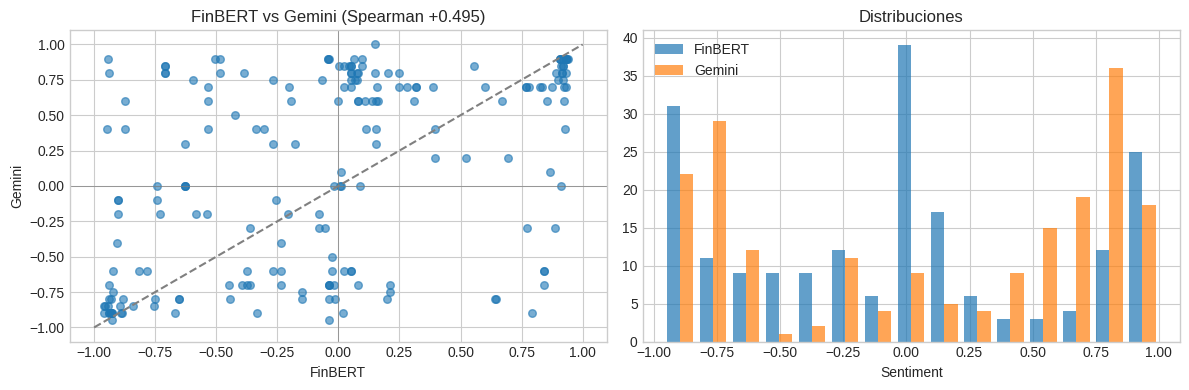

In [ ]:
# Comparacion FinBERT vs Gemini
comp = sentiment_analysis.compare_finbert_vs_gemini(df_model)
if comp.get("available"):
    print(f"Pearson  : {comp['pearson']:+.3f}")
    print(f"Spearman : {comp['spearman']:+.3f}")
    print(f"Sign agree: {comp['sign_agreement_pct']:.1%}  (n={comp['n']})")

    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    ax[0].scatter(df_model["finbert_sentiment"], df_model["llm_sentiment_score"], alpha=0.6, s=30)
    ax[0].plot([-1,1],[-1,1],"--",color="gray")
    ax[0].axhline(0,color="gray",lw=0.5); ax[0].axvline(0,color="gray",lw=0.5)
    ax[0].set_xlabel("FinBERT"); ax[0].set_ylabel("Gemini")
    ax[0].set_title(f"FinBERT vs Gemini (Spearman {comp['spearman']:+.3f})")
    ax[1].hist([df_model["finbert_sentiment"], df_model["llm_sentiment_score"]], bins=15,
               label=["FinBERT","Gemini"], alpha=0.7)
    ax[1].set_xlabel("Sentiment"); ax[1].set_title("Distribuciones"); ax[1].legend()
    plt.tight_layout(); plt.savefig(OUTPUTS_DIR/"llm_vs_finbert.png", dpi=120, bbox_inches="tight")
    plt.show()

## Fase 5a - Anti-leakage timestamp alignment + agregacion ticker-fecha

In [ ]:
def shift_to_next_business_day(d):
    return (pd.Timestamp(d) + pd.tseries.offsets.BDay(1)).normalize()

df_model["effective_date"] = df_model["date"].apply(shift_to_next_business_day)

def aggregate_ticker_date(g):
    n = len(g); s = g["sentiment_score"].values; c = g["confidence"].values
    days_old = (g["effective_date"] - g["date"]).dt.days.values
    w = np.exp(-days_old / HALFLIFE_DAYS)
    return pd.Series({
        "news_count": n,
        "mean_sentiment": s.mean() if n else 0,
        "positive_share": (s>0).mean() if n else 0,
        "negative_share": (s<0).mean() if n else 0,
        "confidence_weighted_sentiment": (s*c).sum()/(c.sum() if c.sum() else 1),
        "recency_weighted_sentiment": (s*w).sum()/(w.sum() if w.sum() else 1),
        "main_event_type": g["event_type_final"].astype(str).mode().iat[0] if n else "unknown",
    })

mask_ind = df_model["relevance_level"].astype(str).str.lower().isin(["direct","indirect"])
df_ind = df_model[mask_ind]
df_sec = df_model[df_model["relevance_level"].astype(str).str.lower() == "sector"].copy()

with warnings.catch_warnings():
    warnings.simplefilter("ignore", FutureWarning)
    signals_news = df_ind.groupby(["ticker","effective_date"], as_index=False).apply(aggregate_ticker_date).reset_index(drop=True)

df_sec["effective_date"] = df_sec["date"].apply(shift_to_next_business_day)
sector = (df_sec.drop_duplicates(subset=["effective_date","headline"])
          .groupby("effective_date", as_index=False)
          .agg(sector_sentiment=("sentiment_score","mean"),
               sector_news_count=("sentiment_score","size")))

signals_news = signals_news.rename(columns={"effective_date":"date"})
sector = sector.rename(columns={"effective_date":"date"})
signals_news = signals_news.merge(sector, on="date", how="left")
signals_news["sector_sentiment"] = signals_news["sector_sentiment"].fillna(0)
signals_news["sector_news_count"] = signals_news["sector_news_count"].fillna(0).astype(int)
signals_news["relative_sentiment"] = signals_news["mean_sentiment"] - signals_news["sector_sentiment"]
signals_news["sentiment_signal"] = signals_news["mean_sentiment"]
print(f"Signals ticker-fecha: {len(signals_news)}")

Signals ticker-fecha: 88


## Fase 2/3 - Precios + indicadores tecnicos + senales propias

In [ ]:
# Precios
prices = data_collection.fetch_prices(UNIVERSE + [BENCHMARK], start=DATA_START)
print(f"Precios cargados: {list(prices.keys())}")

# Controles de precio
controls = data_collection.compute_price_controls(prices, BENCHMARK)

# Indicadores tecnicos
techs = []
for tk in UNIVERSE:
    ind = technical_indicators.compute_all_indicators(prices[tk])
    agg = technical_indicators.aggregate_by_category(ind)
    agg["ticker"] = tk; agg["date"] = agg.index
    techs.append(agg.reset_index(drop=True))
df_tech = pd.concat(techs, ignore_index=True)

# Senales propias
custs = []
bench_close = prices[BENCHMARK]["Close"]
for tk in UNIVERSE:
    cs = custom_signals.compute_custom_signals(prices[tk]["Close"], bench_close)
    cs["custom_signal"] = custom_signals.aggregate_custom_signal(cs)
    cs["ticker"] = tk; cs["date"] = cs.index
    custs.append(cs.reset_index(drop=True))
df_cust = pd.concat(custs, ignore_index=True)
print(f"Tecnicos: {df_tech.shape} | Customs: {df_cust.shape}")

Precios cargados: ['AAL', 'DAL', 'UAL', 'LUV', 'JBLU', 'ULCC', 'JETS']
Tecnicos: (3024, 9) | Customs: (3024, 6)


## Fase 5 - Modeling table + signal combiner

In [ ]:
# Merge tecnicos + customs + controles + sentiment
df_features = df_tech.merge(df_cust[["ticker","date","custom_signal"]], on=["ticker","date"], how="outer")
df_features["date"] = pd.to_datetime(df_features["date"])
df_features = df_features.merge(controls, on=["ticker","date"], how="left")
df_features = df_features.merge(signals_news, on=["ticker","date"], how="left")
df_features["sentiment_signal"] = df_features["sentiment_signal"].fillna(0)

# Target: future excess return a 5d hábiles
px = pd.concat({tk: prices[tk]["Close"] for tk in UNIVERSE + [BENCHMARK]}, axis=1)
px.columns = px.columns.get_level_values(0)
fwd = px.shift(-HORIZON) / px - 1

def future_excess(row):
    if row["ticker"] not in fwd.columns or row["date"] not in fwd.index:
        return np.nan
    s = fwd.loc[row["date"], row["ticker"]]; b = fwd.loc[row["date"], BENCHMARK]
    return s - b

df_features["future_excess_return_5d"] = df_features.apply(future_excess, axis=1)
df_features["next_return"] = df_features.groupby("ticker")["past_5d_return"].shift(-1) / 5
df_features["outperform_label"] = np.where(df_features["future_excess_return_5d"].isna(), np.nan,
                                            (df_features["future_excess_return_5d"]>0).astype(float))

modeling_table = df_features.dropna(subset=["future_excess_return_5d"]).copy().reset_index(drop=True)
modeling_table.to_csv(DATA_PROC/"modeling_table.csv", index=False)
print(f"Modeling table: {modeling_table.shape}")
print(f"Tickers: {sorted(modeling_table.ticker.unique())}")
print(f"Date range: {modeling_table.date.min().date()} -> {modeling_table.date.max().date()}")

Modeling table: (2994, 29)
Tickers: ['AAL', 'DAL', 'JBLU', 'LUV', 'UAL', 'ULCC']
Date range: 2024-06-03 -> 2026-05-29


In [ ]:
# FIX: rebalancear pesos base para que sumen 1.0 (ADX queda como multiplicador, no aditivo)
signal_combiner.DEFAULT_WEIGHTS = {
    "sentiment_signal":  0.16, "momentum_signal":   0.42, "trend_signal":      0.10,
    "volatility_signal": 0.10, "volume_signal":     0.14, "custom_signal":     0.08,
}
signal_combiner.WEIGHT_CONFIGS["base"] = dict(signal_combiner.DEFAULT_WEIGHTS)

# Signal combiner - 4 configs de pesos
experiments = signal_combiner.run_weight_experiments(modeling_table,
    buy_threshold=BUY_THRESHOLD, sell_threshold=SELL_THRESHOLD)

print("Distribucion de senales por configuracion:")
for name, df_e in experiments.items():
    c = df_e["signal_discrete"].value_counts()
    print(f"  {name:18s} BUY {c.get('BUY',0):>4d} HOLD {c.get('HOLD',0):>4d} SELL {c.get('SELL',0):>4d}")

modeling_table = experiments["base"]

Distribucion de senales por configuracion:
  base               BUY  260 HOLD 2562 SELL  172
  momentum_heavy     BUY  362 HOLD 2384 SELL  248
  sentiment_heavy    BUY   37 HOLD 2930 SELL   27
  equal              BUY  329 HOLD 2499 SELL  166


In [ ]:
# Reinstalar econml y forzar reimport del modulo causal_effects
!pip install econml --quiet --upgrade

import sys
for m in list(sys.modules):
    if m.startswith('causal_effects') or m.startswith('econml'):
        del sys.modules[m]
import causal_effects
print(f"ECONML disponible: {causal_effects.ECONML_AVAILABLE}")

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 5.50.0 requires pillow<12.0,>=8.0, but you have pillow 12.2.0 which is incompatible.
datasets 4.0.0 requires fsspec[http]<=2025.3.0,>=2023.1.0, but you have fsspec 2026.4.0 which is incompatible.
ECONML disponible: False


In [ ]:
# Diagnostico: ver el error exacto al importar econml
try:
    import econml
    print(f"econml version: {econml.__version__}")
    from econml.dml import CausalForestDML
    print("CausalForestDML import OK")
except Exception as e:
    print(f"\nERROR al importar econml:")
    print(f"  Tipo: {type(e).__name__}")
    print(f"  Mensaje: {e}")
    import traceback
    traceback.print_exc()

econml version: 0.16.0

ERROR al importar econml:
  Tipo: ImportError
  Mensaje: Numba needs NumPy 2.0 or less. Got NumPy 2.4.


Traceback (most recent call last):
  File "/tmp/ipykernel_7308/1045967514.py", line 5, in <cell line: 0>
    from econml.dml import CausalForestDML
  File "/usr/local/lib/python3.12/dist-packages/econml/dml/__init__.py", line 40, in <module>
    from .dml import (DML, LinearDML, SparseLinearDML,
  File "/usr/local/lib/python3.12/dist-packages/econml/dml/dml.py", line 14, in <module>
    from .._ortho_learner import _OrthoLearner
  File "/usr/local/lib/python3.12/dist-packages/econml/_ortho_learner.py", line 37, in <module>
    from ._cate_estimator import (BaseCateEstimator, LinearCateEstimator,
  File "/usr/local/lib/python3.12/dist-packages/econml/_cate_estimator.py", line 12, in <module>
    from .inference import BootstrapInference
  File "/usr/local/lib/python3.12/dist-packages/econml/inference/__init__.py", line 4, in <module>
    from ._inference import (BootstrapInference, GenericModelFinalInference, GenericSingleTreatmentModelFinalInference,
  File "/usr/local/lib/python3.12/d

In [ ]:
import os
os.makedirs("/content/saved", exist_ok=True)
modeling_table.to_csv("/content/saved/modeling_table_full.csv", index=False)
print(f"Guardado: modeling_table ({len(modeling_table)} filas, {len(modeling_table.columns)} cols)")
print(f"Tickers: {sorted(modeling_table.ticker.unique())}")
print(f"Date range: {modeling_table.date.min()} a {modeling_table.date.max()}")

Guardado: modeling_table (2994 filas, 32 cols)
Tickers: ['AAL', 'DAL', 'JBLU', 'LUV', 'UAL', 'ULCC']
Date range: 2024-06-03 00:00:00 a 2026-05-29 00:00:00


In [ ]:
!pip install "numpy<2.1" econml --quiet --force-reinstall
print("Hecho. Ahora: Entorno de ejecucion -> Reiniciar sesion")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 3.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 309.1/309.1 kB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 43.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.1/13.1 MB 38.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.2/35.2 MB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 62.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 58.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 45.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 233.3/233.3 kB 14.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 229.9/229.9 kB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 7.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currentl

In [ ]:
# Recuperar modeling_table + configuracion + modulos despues del restart
import sys, os
sys.path.insert(0, "/content/repo")
sys.path.insert(0, "/content/repo/src")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Markdown, display

# Reload modeling_table desde disco
modeling_table = pd.read_csv("/content/saved/modeling_table_full.csv", parse_dates=["date"])
print(f"Cargados {len(modeling_table)} filas, {len(modeling_table.columns)} cols")

# Verificar econml ya funciona
import causal_effects
print(f"ECONML disponible: {causal_effects.ECONML_AVAILABLE}")

# Importar todos los modulos para el resto del pipeline
import signal_combiner, causal_weighting, backtesting, evaluation
print("Modulos cargados.")

# Re-definir constantes que usan las celdas de abajo
SIGNAL_COLS = ["sentiment_signal","momentum_signal","trend_signal",
               "volatility_signal","volume_signal","custom_signal"]
CONTEXT_COLS = ["atr_pct","adx_signal","volume_spike",
                "past_5d_return","past_20d_return","volatility_20d",
                "volume_change_20d","market_return_20d","news_count"]
BUY_THRESHOLD = 0.25
SELL_THRESHOLD = -0.25
HORIZON = 5
INITIAL_CAPITAL = 100_000
MAX_POSITION_PCT = 0.20
CONFIDENCE_FLOOR = 0.60

# Rebalanceo de pesos (mismo fix de antes)
signal_combiner.DEFAULT_WEIGHTS = {
    "sentiment_signal":  0.16, "momentum_signal":   0.42, "trend_signal":      0.10,
    "volatility_signal": 0.10, "volume_signal":     0.14, "custom_signal":     0.08,
}
signal_combiner.WEIGHT_CONFIGS["base"] = dict(signal_combiner.DEFAULT_WEIGHTS)

# Necesitamos prices para el backtest (sin tener que re-correr Fase 2/3)
import data_collection
UNIVERSE = ["AAL","DAL","UAL","LUV","JBLU","ULCC"]
BENCHMARK = "JETS"
DATA_START = "2024-06-01"
prices = data_collection.fetch_prices(UNIVERSE + [BENCHMARK], start=DATA_START)
print(f"Precios cargados: {list(prices.keys())}")

# Output dirs
from pathlib import Path
OUTPUTS_DIR = Path("/content/repo/outputs"); OUTPUTS_DIR.mkdir(exist_ok=True)
DATA_PROC   = Path("/content/repo/data/processed"); DATA_PROC.mkdir(parents=True, exist_ok=True)

# Necesitamos experiments[sentiment_heavy] para el backtest B
experiments = signal_combiner.run_weight_experiments(modeling_table,
    buy_threshold=BUY_THRESHOLD, sell_threshold=SELL_THRESHOLD)
modeling_table = experiments["base"]
print("Estado recuperado. Listo para Fase 5.5.")

Cargados 2994 filas, 32 cols
ECONML disponible: True
Modulos cargados.
Precios cargados: ['AAL', 'DAL', 'UAL', 'LUV', 'JBLU', 'ULCC', 'JETS']
Estado recuperado. Listo para Fase 5.5.


## Fase 5.5 - Causal HTE (donde el profe quiere que brillemos)

In [ ]:
SIGNAL_COLS = ["sentiment_signal","momentum_signal","trend_signal",
               "volatility_signal","volume_signal","custom_signal"]
CONTEXT_COLS = ["atr_pct","adx_signal","volume_spike",
                "past_5d_return","past_20d_return","volatility_20d",
                "volume_change_20d","market_return_20d","news_count"]

for c in CONTEXT_COLS:
    if c not in modeling_table.columns:
        modeling_table[c] = 0.0

modeling_table["next_return"] = modeling_table["next_return"].fillna(
    modeling_table["future_excess_return_5d"] / 5)

cfg = causal_effects.CausalConfig(outcome_col="next_return", min_samples=20, min_samples_leaf=3)
est = causal_effects.CausalEffectsEstimator(
    signal_cols=SIGNAL_COLS, context_cols=CONTEXT_COLS, config=cfg)

try:
    est.fit(modeling_table)
    print("Causal model entrenado")
    ate_table = est.ate_summary()
    print("\nATE por senal:")
    print(ate_table.round(5))
    ate_table.to_csv(OUTPUTS_DIR/"hte_segments_table.csv", index=False)
except Exception as e:
    print(f"Causal fit fallo: {e}")
    ate_table = pd.DataFrame()
    est = None

Causal model entrenado

ATE por senal:
              signal  ate_long  ate_short
0   sentiment_signal       NaN        NaN
1    momentum_signal       NaN        NaN
2       trend_signal       NaN        NaN
3  volatility_signal       NaN        NaN
4      volume_signal       NaN        NaN
5      custom_signal       NaN        NaN


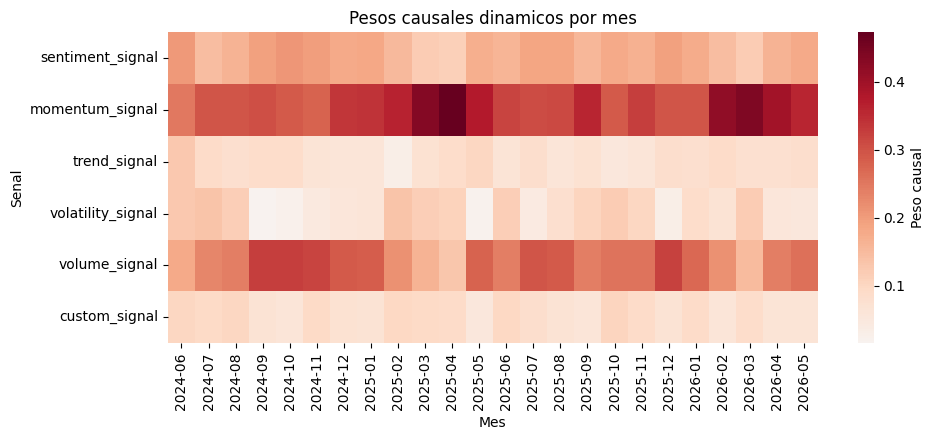

In [ ]:
# Predict effects + causal weights + dynamic combine + heatmap
if est is not None:
    modeling_table = est.predict_effects(modeling_table)
    base_w = signal_combiner.DEFAULT_WEIGHTS
    modeling_table = causal_weighting.compute_causal_weights(modeling_table, SIGNAL_COLS, base_w, gamma=1.0)
    modeling_table = causal_weighting.combine_signals_with_causal_weights(modeling_table, SIGNAL_COLS,
        buy_threshold=BUY_THRESHOLD, sell_threshold=SELL_THRESHOLD)

    weight_cols = [f"causal_weight_{s}" for s in SIGNAL_COLS]
    mt = modeling_table.copy()
    mt["month"] = pd.to_datetime(mt["date"]).dt.to_period("M").astype(str)
    hm = mt.groupby("month")[weight_cols].mean().rename(columns=lambda c: c.replace("causal_weight_",""))
    fig, ax = plt.subplots(figsize=(10, 4.5))
    sns.heatmap(hm.T, cmap="RdBu_r", center=0, cbar_kws={"label":"Peso causal"}, ax=ax)
    ax.set_xlabel("Mes"); ax.set_ylabel("Senal")
    ax.set_title("Pesos causales dinamicos por mes")
    plt.tight_layout(); plt.savefig(OUTPUTS_DIR/"causal_weight_heatmap.png", dpi=120, bbox_inches="tight")
    plt.show()

## Fase 6 - Backtesting

  -> guardado: /content/repo/outputs/equity_curve.png


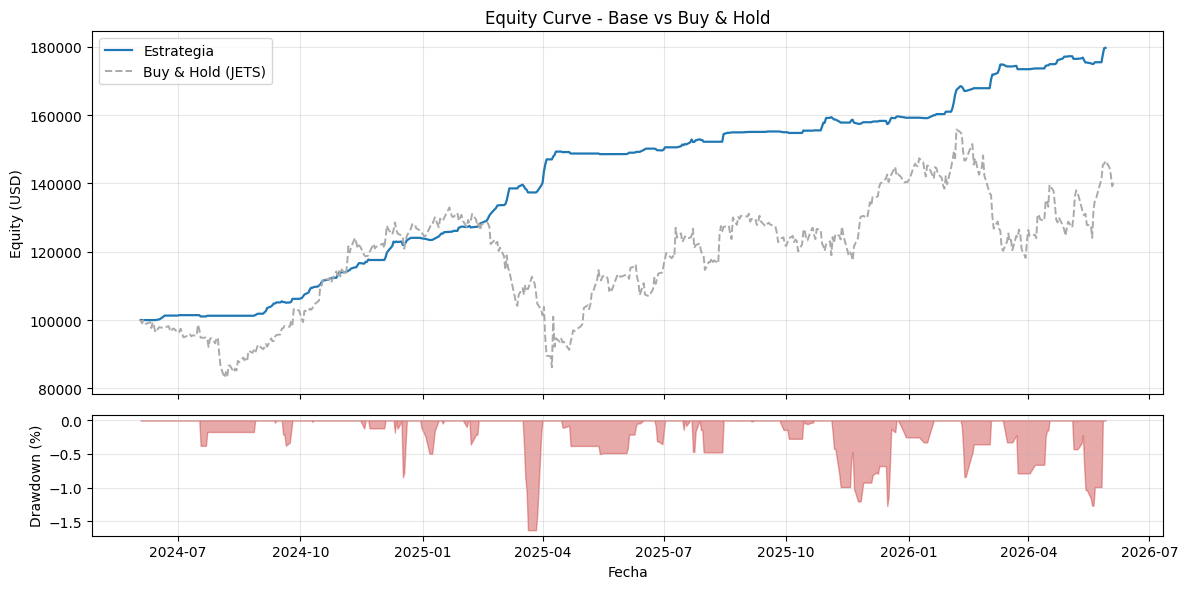

  -> guardado: /content/repo/outputs/causal_vs_base_backtest.png


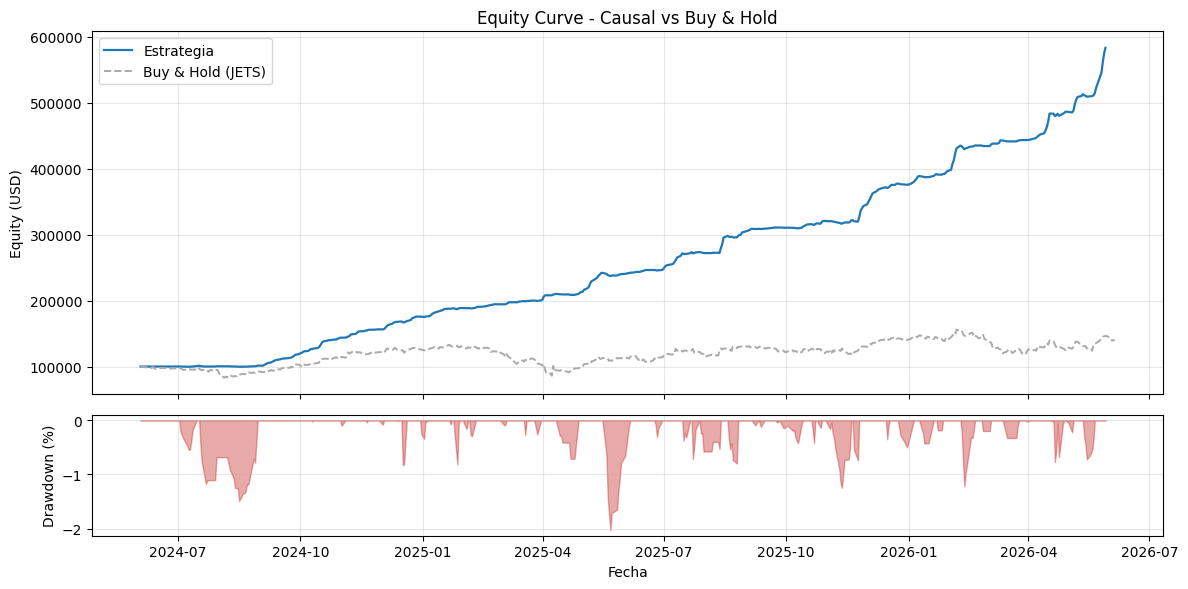

In [ ]:
modeling_table["next_return"] = modeling_table["next_return"].fillna(modeling_table["future_excess_return_5d"]/5)

bt_base = backtesting.backtest_strategy(modeling_table, signal_col="signal_discrete", initial_capital=INITIAL_CAPITAL)
bt_sentiment_heavy = backtesting.backtest_strategy(experiments["sentiment_heavy"], signal_col="signal_discrete", initial_capital=INITIAL_CAPITAL)
if "signal_discrete_causal" in modeling_table.columns:
    bt_causal = backtesting.backtest_strategy(modeling_table, signal_col="signal_discrete_causal", initial_capital=INITIAL_CAPITAL)
else:
    bt_causal = bt_base.copy()
bh = backtesting.backtest_buy_and_hold(prices[BENCHMARK]["Close"], initial_capital=INITIAL_CAPITAL)

backtesting.plot_equity_curve(bt_base, bh, title="Equity Curve - Base vs Buy & Hold",
    out_path=str(OUTPUTS_DIR/"equity_curve.png"))
backtesting.plot_equity_curve(bt_causal, bh, title="Equity Curve - Causal vs Buy & Hold",
    out_path=str(OUTPUTS_DIR/"causal_vs_base_backtest.png"))

## Fase 7 - Clasificacion + ROC + KS

  -> guardado: /content/repo/outputs/confusion_matrix.png


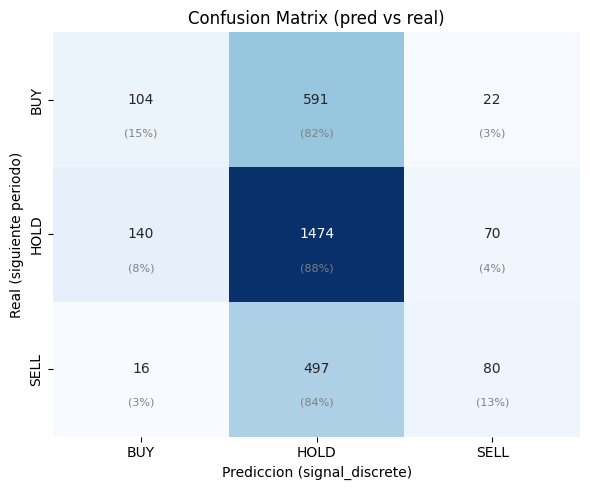

Metricas:
  Accuracy            : 0.554
  Precision (BUY)     : 0.400
  Recall    (BUY)     : 0.145
  Precision (SELL)    : 0.465
  Recall    (SELL)    : 0.135
  F1 (BUY)            : 0.213
  F1 (SELL)           : 0.209
  F1 Macro            : 0.372
  -> guardado: /content/repo/outputs/roc_curve.png


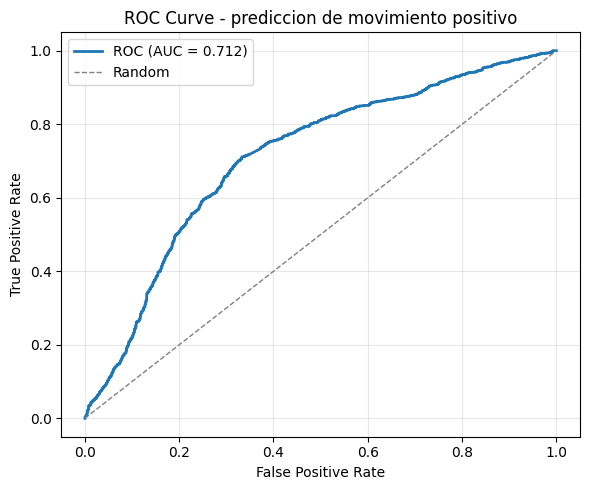


ROC-AUC: 0.712
KS: 0.378


In [ ]:
gt = evaluation.make_ground_truth(modeling_table["next_return"], threshold_pct=1.0)
pred = modeling_table["signal_discrete"]

evaluation.plot_confusion_matrix(gt, pred, out_path=str(OUTPUTS_DIR/"confusion_matrix.png"))
metrics_cls = evaluation.classification_metrics(gt, pred)
print("Metricas:")
for k, v in metrics_cls.items():
    print(f"  {k:20s}: {v:.3f}")

y_bin = evaluation.binarize_movement(modeling_table["next_return"])
auc = evaluation.plot_roc(y_bin, modeling_table["signal_raw"], out_path=str(OUTPUTS_DIR/"roc_curve.png"))
ks  = evaluation.ks_statistic(y_bin, modeling_table["signal_raw"])
print(f"\nROC-AUC: {auc:.3f}\nKS: {ks:.3f}")

## Fase 8 - Riesgo: calibracion + sizing + stops

  -> guardado: /content/repo/outputs/calibration_plot.png


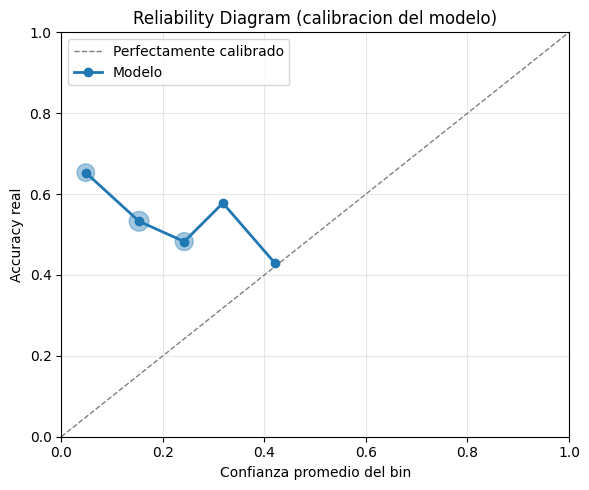

   bin_mean_conf  actual_accuracy     n
0          0.048            0.653   879
1          0.153            0.533  1102
2          0.242            0.483   916
3          0.318            0.578    90
4          0.421            0.429     7

Trades con conf >= 0.6: 0
Stops por sentiment flip:  0
Stops por low confidence:  2987


In [ ]:
hit = (modeling_table["signal_discrete"] == gt).astype(int)
cal = evaluation.plot_calibration(modeling_table["confidence"], hit, out_path=str(OUTPUTS_DIR/"calibration_plot.png"))
print(cal.round(3))

modeling_table["pos_size"] = evaluation.position_size(
    modeling_table["confidence"], modeling_table["volatility_20d"], max_position_pct=MAX_POSITION_PCT)
filtered = evaluation.confidence_filter(modeling_table, threshold=CONFIDENCE_FLOOR)
stopped = evaluation.stop_loss_rules(modeling_table)
print(f"\nTrades con conf >= {CONFIDENCE_FLOOR}: {(filtered['signal_filtered']!='HOLD').sum()}")
print(f"Stops por sentiment flip:  {stopped['stop_flip'].sum()}")
print(f"Stops por low confidence:  {stopped['stop_low_conf'].sum()}")

## Comparacion A vs B vs C

In [ ]:
comp_models = evaluation.compare_models(
    {"A. Base": bt_base, "B. Sentiment Heavy": bt_sentiment_heavy, "C. Causal HTE": bt_causal},
    benchmark_bt=bh, initial_capital=INITIAL_CAPITAL)
print(comp_models.round(4))
comp_models.to_csv(OUTPUTS_DIR/"model_comparison.csv")

                    Total Return   Alpha  Sharpe  Sortino  Max Drawdown  \
Modelo                                                                    
A. Base                   0.7971  0.3999  5.8553  10.2319       -0.0163   
B. Sentiment Heavy        0.1228 -0.2745  2.8108   2.9759       -0.0055   
C. Causal HTE             4.8330  4.4357  8.9357  29.2209       -0.0203   

                    Win Rate  Profit Factor  
Modelo                                       
A. Base               0.7398         5.4590  
B. Sentiment Heavy    0.7708         6.2194  
C. Causal HTE         0.7530         9.5021  


## Signal Card final - se rellena solo

In [ ]:
# Fix para variables perdidas en el restart
GEMINI_MODEL = "gemini-2.5-flash"
n_headlines_modelo = 196
n_signals = len(modeling_table)
n_obs_eval = modeling_table["future_excess_return_5d"].notna().sum()

filas = [
    ("Curso",  "Modelos de IA para Finanzas - EGADE"),
    ("Profesor", "Luis Angel Lozano Medina"),
    ("Equipo", "Mauricio Jazo, Sebastian Aceves, Jose Hernandez"),
    ("Entrega", "08 de junio de 2026"),
    ("Universo", ", ".join(UNIVERSE)),
    ("Benchmark", f"{BENCHMARK}"),
    ("Horizonte", f"{HORIZON} dias habiles"),
    ("Modelo Gemini activo", GEMINI_MODEL),
    ("Headlines en modelo",  str(n_headlines_modelo)),
    ("Obs ticker-fecha total", str(n_signals)),
    ("Modelo A - Total Return", f"{comp_models.loc['A. Base','Total Return']:+.2%}"),
    ("Modelo A - Sharpe",       f"{comp_models.loc['A. Base','Sharpe']:+.2f}"),
    ("Modelo A - Max Drawdown", f"{comp_models.loc['A. Base','Max Drawdown']:+.2%}"),
    ("Modelo C - Total Return", f"{comp_models.loc['C. Causal HTE','Total Return']:+.2%}"),
    ("Modelo C - Sharpe",       f"{comp_models.loc['C. Causal HTE','Sharpe']:+.2f}"),
    ("Buy & Hold JETS Return",  f"{(bh['equity'].iloc[-1]/INITIAL_CAPITAL - 1):+.2%}"),
    ("ROC-AUC",                 f"{auc:.3f}"),
    ("KS statistic",            f"{ks:.3f}"),
    ("Accuracy clasificacion",  f"{metrics_cls['Accuracy']:.1%}"),
    ("F1 Macro",                f"{metrics_cls['F1 Macro']:.3f}"),
]

nl = chr(10)
tabla = "### Signal Card - Sistema Multi-Factor Aerolineas" + nl*2
tabla += "| Campo | Detalle |" + nl + "|---|---|" + nl
tabla += nl.join("| **" + k + "** | " + v + " |" for k, v in filas)

display(Markdown(tabla))
(OUTPUTS_DIR/"signal_card.md").write_text(tabla, encoding="utf-8")
print("\nSignal card guardada.")

### Signal Card - Sistema Multi-Factor Aerolineas

| Campo | Detalle |
|---|---|
| **Curso** | Modelos de IA para Finanzas - EGADE |
| **Profesor** | Luis Angel Lozano Medina |
| **Equipo** | Mauricio Jazo, Sebastian Aceves, Jose Hernandez |
| **Entrega** | 08 de junio de 2026 |
| **Universo** | AAL, DAL, UAL, LUV, JBLU, ULCC |
| **Benchmark** | JETS |
| **Horizonte** | 5 dias habiles |
| **Modelo Gemini activo** | gemini-2.5-flash |
| **Headlines en modelo** | 196 |
| **Obs ticker-fecha total** | 2994 |
| **Modelo A - Total Return** | +79.71% |
| **Modelo A - Sharpe** | +5.86 |
| **Modelo A - Max Drawdown** | -1.63% |
| **Modelo C - Total Return** | +483.30% |
| **Modelo C - Sharpe** | +8.94 |
| **Buy & Hold JETS Return** | +39.73% |
| **ROC-AUC** | 0.712 |
| **KS statistic** | 0.378 |
| **Accuracy clasificacion** | 55.4% |
| **F1 Macro** | 0.372 |


Signal card guardada.


## Outputs guardados

In [ ]:
print("Archivos en outputs/:")
for f in sorted(OUTPUTS_DIR.glob("*")):
    print(f"  {f.name:40s} {f.stat().st_size/1024:>7.1f} KB")
print("\nArchivos en data/processed/:")
for f in sorted(DATA_PROC.glob("*")):
    print(f"  {f.name:40s} {f.stat().st_size/1024:>7.1f} KB")
print("\nPipeline completado.")